# HR Analytics Employee Attrition & Performance
## Business Objective

The objective of this project is to identify the factors associated with employee attrition and provide actionable recommendations that may help improve employee retention.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

# Load the dataset

In [20]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')


# Data Understanding

In [21]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [22]:
df.shape# Returns a tuple (rows, columns)

(1470, 35)

In [23]:
df.info()# # Displays column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [24]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [25]:
df.isnull().sum()#Count missing values per column — none found in this dataset

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [26]:
df.duplicated().sum()

np.int64(0)


# What percentage of employees leave the company?

In [27]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [28]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

# Visualize the Attrition

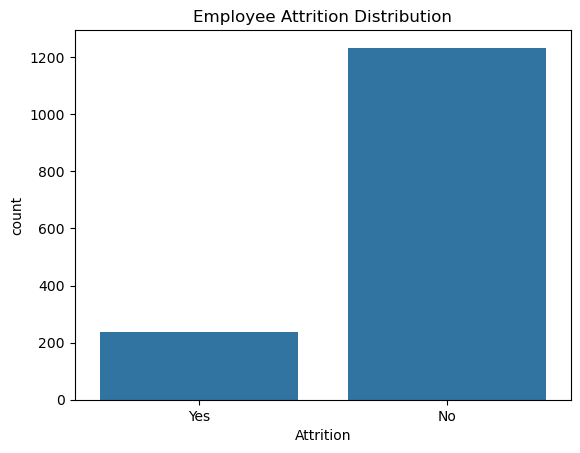

In [29]:
plt.figure()
sns.countplot(x=df['Attrition'])
plt.title('Employee Attrition Distribution')
plt.show()

**Most employees remain with the company.
However, a significant percentage leave, which can create recruitment and training costs.**

## Does overtime affect employee attrition?

In [30]:
pd.crosstab(df['OverTime'],df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


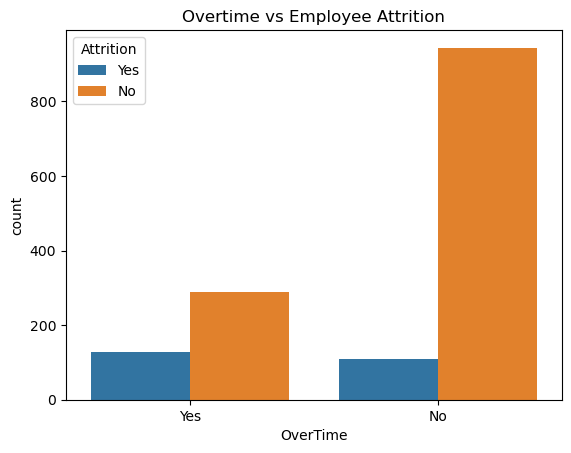

In [31]:
plt.figure()
sns.countplot(x=df['OverTime'],hue=df['Attrition'])
plt.title('Overtime vs Employee Attrition')
plt.show()

Overtime workers: ~130 left out of ~420 total → roughly 1 in 3 left
No overtime workers: ~110 left out of ~1060 total → roughly 1 in 10 left

That is a massive difference. Employees who work overtime are 3 times more likely to leave than those who don't.

# Does monthly income affect employee attrition?

<function matplotlib.pyplot.show(close=None, block=None)>

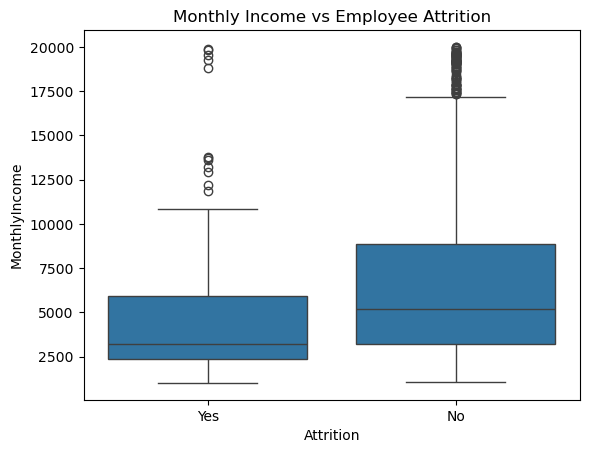

In [32]:
plt.figure()
sns.boxplot(x=df['Attrition'],y=df['MonthlyIncome'])
plt.title('Monthly Income vs Employee Attrition')
plt.show
            

The main finding — lower income employees leave more:
Employees who left had a median monthly income of ~$3,000, while employees who stayed had a median of ~$6,000 — that is double the income. This is a very strong and clear signal.

Both groups have outliers at the top — a few very high earners (~$19,000–$20,000) appear in both groups. But notice the Yes group has very few outliers, meaning almost no high-paid employees chose to leave.

# Which departments have the highest attrition rates?

In [33]:
pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


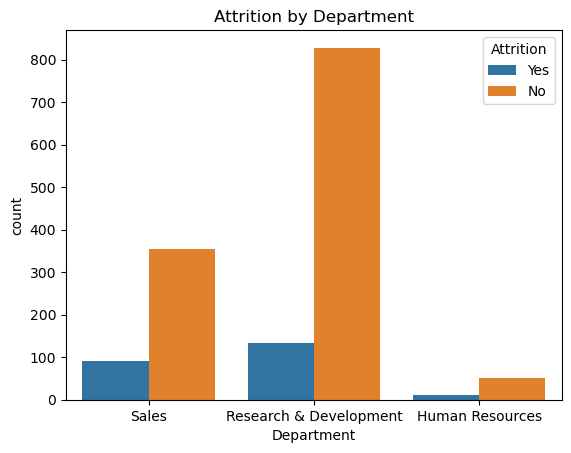

In [34]:
plt.figure()
sns.countplot(x=df['Department'],hue= df['Attrition'])
plt.title('Attrition by Department')
plt.show()

1 — Human Resources has the highest attrition rate (~27%)

Despite being the smallest department, proportionally it loses the most people.
2 — Sales is also struggling (~22%)

About 1 in 5 sales employees left — high pressure, target-driven work likely contributes to this.
3 — R&D retains employees the best (~15%)

Despite being the largest department, it has the healthiest retention — possibly due to higher salaries and more engaging work.


# Does job satisfaction affect employee attrition?


In [35]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
)

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [36]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


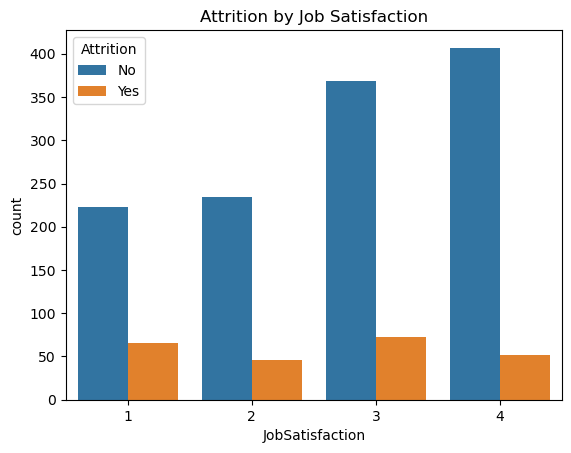

In [37]:
plt.figure()
sns.countplot(
    x=df['JobSatisfaction'],
    hue=df['Attrition'])
plt.title('Attrition by Job Satisfaction')
plt.show()

The main finding:
Employees with very low satisfaction (1) have the highest attrition rate (22%). Employees with high satisfaction (4) have the lowest (~11%) — almost double the difference. The general trend is clear: the happier the employee, the less likely they are to leave.

Something interesting though:
Satisfaction level 2 (16%) has lower attrition than level 3 (17%) — which is the opposite of what you would expect. This happens because the difference is very small and could simply be random variation in the data. To know for sure you would need a statistical test.

# Does work-life balance affect employee attrition?

In [38]:
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'])

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [39]:
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


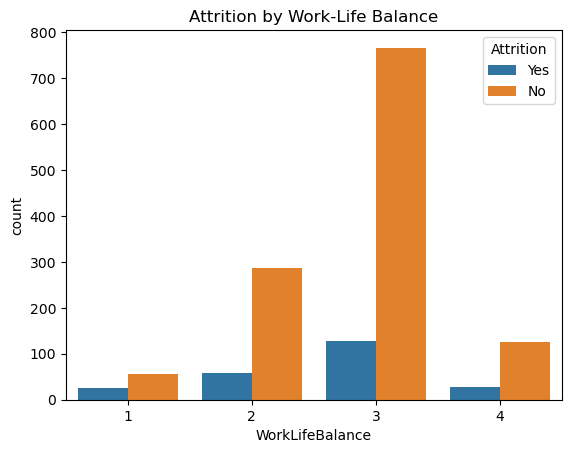

In [40]:
plt.figure()
sns.countplot(
    x=df['WorkLifeBalance'],
    hue=df['Attrition'] ) 
plt.title('Attrition by Work-Life Balance')
plt.show()

 Work-life balance may play an important role in employee retention.
 
 Employees with poor balance may be more likely to leave.
 
Level 1 (very bad work-life balance) is extremely dangerous — nearly 1 in 2 employees left. That is by far the worst attrition rate of any category you have seen so far in this analysis.



# Does tenure affect employee attrition?

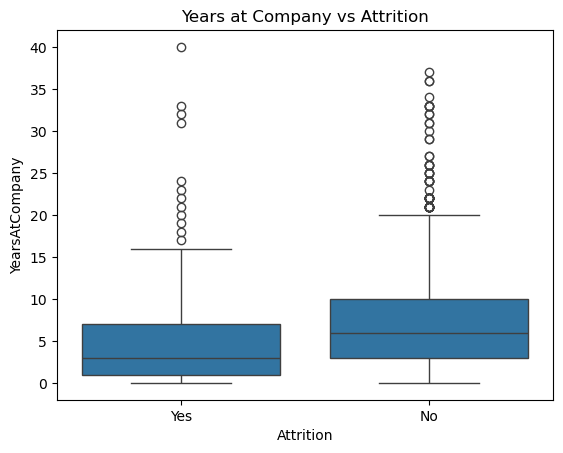

In [41]:
plt.figure()
sns.boxplot(
    x=df['Attrition'],
    y=df['YearsAtCompany'])
plt.title('Years at Company vs Attrition')
plt.show()

Employees who left have a median of only ~4 years at the company, while those who stayed have a median of ~6 years — newer employees are more at risk.

Two things to notice:
1 — The Yes box sits much lower

The entire box of employees who left is compressed in the 1–7 year range. Very few long-tenured employees chose to leave.
2 — Many outliers in the Yes group

There are many circles above the whisker for Yes — employees who had been there 20, 25, 32, even 40 years and still left. These are unusual cases but worth investigating — long-tenured employees who leave may signal a specific internal problem like restructuring or management changes.

# Executive Summary

The objective of this project was to analyze employee attrition and identify the key factors influencing employee turnover.

Using HR analytics data, we examined the impact of overtime, monthly income, department, job satisfaction, work-life balance, and years at the company on employee retention.

The analysis revealed that overtime work, low income, poor work-life balance, and low job satisfaction are strongly associated with higher attrition rates. Additionally, Human Resources and Sales departments experienced higher turnover compared to other departments.

The findings provide valuable insights that can help organizations improve employee retention, reduce turnover costs, and create a more productive work environment.


# Conclusions

* Most employees remain with the company; however, employee attrition remains significant and may generate considerable recruitment and training costs.

* Employees working overtime are substantially more likely to leave the company compared to employees who do not work overtime.

* Monthly income appears to be a major factor affecting retention, as employees with lower salaries show a higher tendency to leave.

* Human Resources and Sales departments exhibit the highest attrition rates, indicating potential department-specific challenges.

* Job satisfaction has a strong relationship with employee retention. Employees reporting lower satisfaction levels are more likely to leave the organization.

* Work-life balance also plays an important role in employee retention. Poor work-life balance is associated with significantly higher attrition rates.

* Employees with fewer years at the company are generally more likely to leave, while long-tenured employees tend to remain with the organization.


# Recommendations

Based on the findings of this analysis, the following actions are recommended:

1. Reduce excessive overtime and monitor employee workload to minimize burnout and improve retention.

2. Review compensation policies, particularly for lower-income employees, to ensure salaries remain competitive.

3. Conduct employee feedback surveys within the Human Resources and Sales departments to identify the causes of higher turnover.

4. Invest in initiatives that improve employee satisfaction, including recognition programs, career development opportunities, and positive workplace culture.

5. Promote a healthy work-life balance through flexible work arrangements and employee wellness initiatives.

6. Strengthen onboarding and support programs for new employees, as attrition is higher among employees with fewer years of service.

7. Continuously monitor employee retention metrics and use data-driven decision-making to identify emerging workforce challenges.

